# Diamonds Visualization Exercises

## Goal
Practice a few core Seaborn chart types on the classic diamonds dataset and see how the same table looks through different visual summaries.

## Data
The notebook uses `data/diamonds.csv`, a public tabular dataset with price, carat, cut, color, and clarity information for about 54,000 diamonds.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120


In [2]:
def resolve_data_path() -> Path:
    candidates = [
        Path('data/diamonds.csv'),
        Path('../data/diamonds.csv'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not find data/diamonds.csv relative to this notebook.')

data_path = resolve_data_path()
diamonds = pd.read_csv(data_path)
diamonds[['carat', 'cut', 'color', 'clarity', 'price']].head()


,carat,cut,color,clarity,price
0,0.23,Ideal,E,SI2,326
1,0.21,Premium,E,SI1,326
2,0.23,Good,E,VS1,327
3,0.29,Premium,I,VS2,334
4,0.31,Good,J,SI2,335


In [3]:
diamonds.shape, diamonds['cut'].value_counts().sort_index()


((53940, 10),
 cut
 Fair          1610
 Good          4906
 Ideal        21551
 Premium      13791
 Very Good    12082
 Name: count, dtype: int64)

## Scatter Plot
Price generally rises with carat, but the heavier overlap is easier to read once transparency is reduced and the canvas is widened.


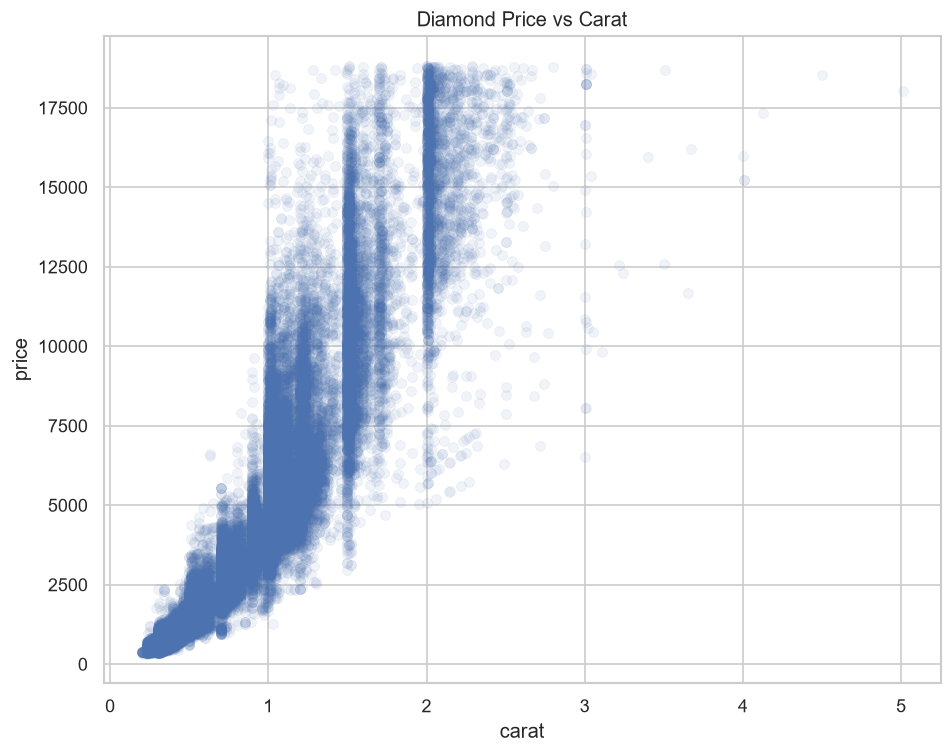

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=diamonds, x='carat', y='price', alpha=0.08, edgecolor=None, ax=ax)
ax.set_title('Diamond Price vs Carat')
plt.show()


## Histogram
The price distribution is strongly right-skewed, so most stones cluster in the lower price range.


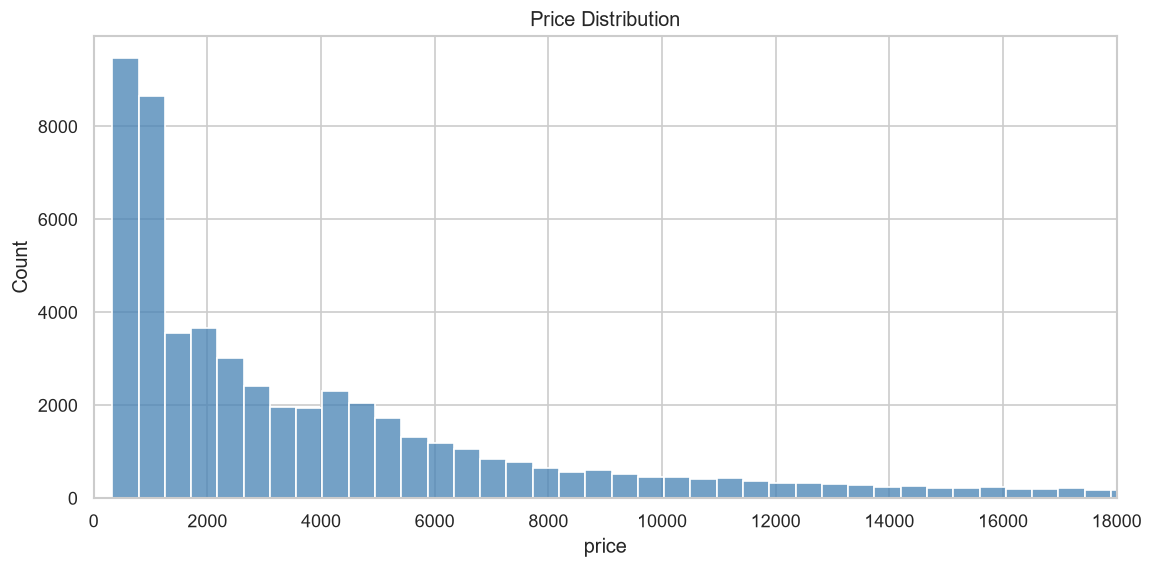

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(diamonds, x='price', bins=40, color='steelblue', ax=ax)
ax.set_xlim(0, 18000)
ax.set_title('Price Distribution')
plt.show()


## Count Plot
This view only tracks frequency, so it is a quick way to see which cut grades appear most often.


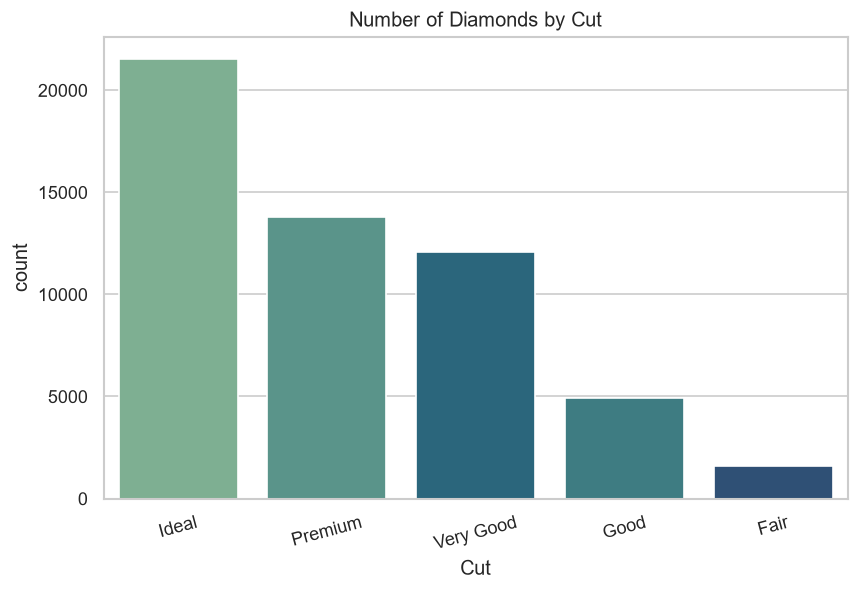

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=diamonds, x='cut', hue='cut', order=diamonds['cut'].value_counts().index, palette='crest', legend=False, ax=ax)
ax.set_title('Number of Diamonds by Cut')
ax.set_xlabel('Cut')
plt.xticks(rotation=15)
plt.show()


## Box Plot
Ordering the categories by median price makes the distribution shift easier to compare than alphabetical ordering.


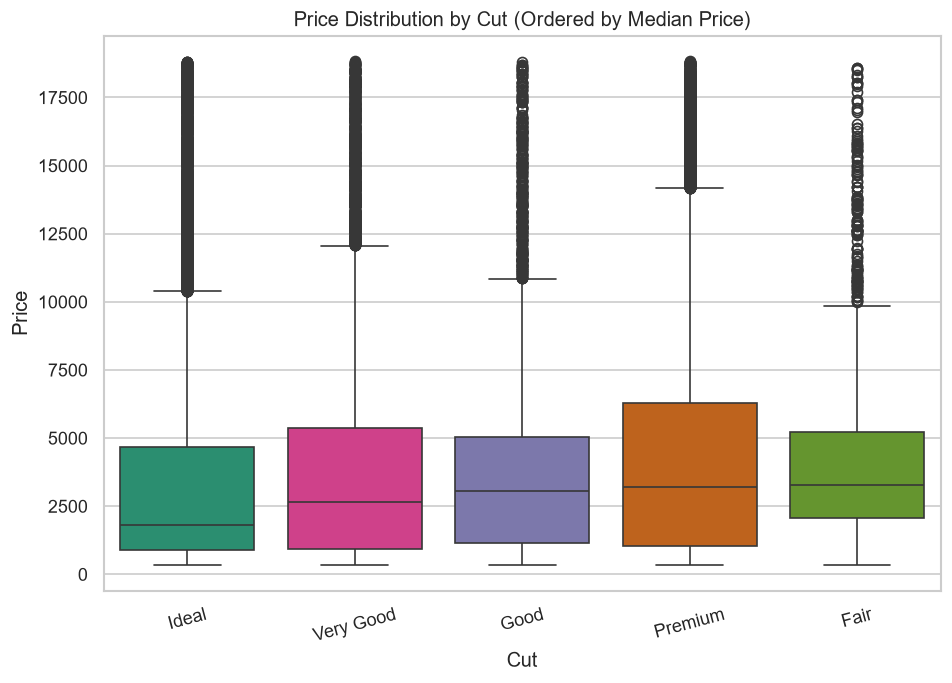

In [7]:
median_order = diamonds.groupby('cut')['price'].median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=diamonds, x='cut', y='price', hue='cut', order=median_order, palette='Dark2', legend=False, ax=ax)
ax.set_title('Price Distribution by Cut (Ordered by Median Price)')
ax.set_xlabel('Cut')
ax.set_ylabel('Price')
plt.xticks(rotation=15)
plt.show()


## What I Learned
- Transparency matters when a scatter plot has heavy overplotting.
- Histograms and box plots highlight different parts of the same distribution.
- Reordering categories can make a categorical comparison easier to interpret.

## Limits
These plots are descriptive only. They help reveal shape and relationships in the dataset, but they do not explain causation or control for other diamond attributes at the same time.
